# Attenuation Dashboard

Companion to [`03_reform_narrative.ipynb`](03_reform_narrative.ipynb) and [`05_engineering_decomposition.ipynb`](05_engineering_decomposition.ipynb). Notebook 03 documented the **quantity** signature of market-power attenuation at the MTU15-IDA reform: Big-4 dominant low-wind $|\Delta Q|$ collapsed from $-271$ to $-78$ MWh/unit-day (a 71% step). Notebook 05 ruled out four mechanical channels (profile-matching, ramp-lumpiness, reserve substitution, storage internalisation) that could have produced the same pattern without any behavioural change.

This notebook runs the **bid-level corroboration**. If the MTU15-IDA compression is behavioural — if Big-4 dominants stopped exploiting the DA-IDA spread once finer intraday clearing collapsed the arbitrage — it should show up in *three independent bid-level measures*:

| § | Test | Economic content | Attenuation prediction |
|---|---|---|---|
| 2 | Mean CCGT IDA bid (EUR/MWh), Big-4 vs Fringe | Bid level in the reform-affected market; proxies Cournot shading | Big-4 IDA bid **converges toward Fringe IDA bid** at MTU15-IDA |
| 3 | Ito-Reguant $\beta$: $\Delta Q$ on lagged DA-IDA spread | Sensitivity of firm-day repositioning to the anticipated arbitrage opportunity | Big-4 $\beta$ **flattens toward Fringe $\beta$** at MTU15-IDA |
| 4 | Within-hour DA price dispersion (post-MTU15-DA) | Whether the DA market prices solar-ramp and load-ramp structure at quarter-hour resolution — empirical support for the *thinness channel* in `theory/granularity_extension.tex` | Non-trivial within-hour dispersion, concentrated in solar-transition hours |

§2 and §3 run on the nb03 §3e regime grid (pre-IDA / 3-session / ISP15 / MTU15-IDA / MTU15-DA) with the Big-4 / Fringe classification. §4 runs only post-2025-10-01 (MTU15-DA) because that is when within-hour DA prices become observable.

**Why IDA not DA for the bid-level test.** Pre-MTU15-IDA DA `det` files use a different fixed-width layout whose price column is consistently 0-padded in our current parser — the pre-reform DA bid distribution is a degenerate spike at zero across all units. IDA bid data (`idet`) is clean across both regimes, and the MTU15-IDA reform directly concerns intraday clearing anyway, so the test is more directly aligned with the reform lever. A proper DA-bid-level test requires fixing the parser; we flag that for a separate pass.

**Scope.** Descriptive only — pattern consistency, not causal effect size.

## § 0 — Setup

All reform dates, regime windows, and the Big-4 / Fringe classification are loaded from `mtu.notebook_utils` and from `pibcie_all.parquet` (`grupo_empresarial`), matching nb03 and nb05. The DuckDB connection uses an 8 GB memory limit because §2 joins the full DA offer-tranche table.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mtu.notebook_utils import (
    PROJECT_ROOT,
    REGIME_WINDOWS, REGIME_COLORS,
)

# OMIE tables used throughout.
ICAB         = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/ofertas/icab_all.parquet'
IDET         = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/ofertas/idet_all.parquet'
PDBC         = PROJECT_ROOT / 'data/processed/omie/mercado_diario/programas/pdbc_all.parquet'
MARGINALPDBC = PROJECT_ROOT / 'data/processed/omie/mercado_diario/precios/marginalpdbc_all.parquet'
MARGINALPIBC = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/precios/marginalpibc_all.parquet'
PIBCI        = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/programas/pibci_all.parquet'
PIBCIE       = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/programas/pibcie_all.parquet'
UNITS        = PROJECT_ROOT / 'data/external/omie_reference/lista_unidades.csv'

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

con = duckdb.connect()
con.execute("SET memory_limit='8GB'")
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")

# Analysis window matches nb03 / nb05.
START = '2023-12-01'

# Big-4 classification: unit_code → grupo_empresarial from pibcie.
# ARG_MAX over date gives the most recent classification per unit (robust to
# reclassifications; in practice grupo_empresarial is stable for generators).
con.execute(f"""
    CREATE OR REPLACE TABLE unit_group AS
    SELECT unit_code,
           ARG_MAX(grupo_empresarial, date) AS grupo_empresarial
    FROM read_parquet('{PIBCIE}')
    WHERE unit_code IS NOT NULL AND grupo_empresarial IS NOT NULL
    GROUP BY unit_code
""")

BIG4 = ('IB', 'GN', 'GE', 'HC')

# Technology lookup (needed for CCGT subset in §2).
con.execute(f"""
    CREATE OR REPLACE TABLE unit_tech AS
    SELECT unit_code, technology FROM read_csv_auto('{UNITS}')
""")

# Regime-assignment SQL snippet, parametrised by a date column reference.
REGIME_CASE = """
    CASE
        WHEN {d} <= '2024-06-13' THEN 'DA60/ID60 (6-sess)'
        WHEN {d} <= '2024-11-30' THEN 'DA60/ID60 (3-sess)'
        WHEN {d} <= '2025-03-18' THEN 'ISP15 window'
        WHEN {d} <= '2025-09-30' THEN 'DA60/ID15'
        ELSE 'DA15/ID15'
    END
"""

REGIME_ORDER = [label for label, _, _ in REGIME_WINDOWS]

print(f'Analysis window: {START} → open')
print(f'Big-4 codes: {BIG4}')
print(f'Regime order: {REGIME_ORDER}')

Analysis window: 2023-12-01 → open
Big-4 codes: ('IB', 'GN', 'GE', 'HC')
Regime order: ['DA60/ID60 (6-sess)', 'DA60/ID60 (3-sess)', 'ISP15 window', 'DA60/ID15', 'DA15/ID15']


## § 2 — Mean IDA bid level (CCGT)

**Definition.** For each IDA sell tranche of a CCGT unit, we compute the quantity-weighted mean bid in regime $r$ and group $g$:

$$\bar{p}^{\text{IDA}}_{g,r} \;=\; \frac{\sum_{i,t,h,s,k}\;s_{i,t,h,s,k}\,q_{i,t,h,s,k}\,\tau \cdot \mathbf{1}\{i\in g\cap\text{CCGT},\, t\in r\}}{\sum_{i,t,h,s,k}\;q_{i,t,h,s,k}\,\tau \cdot \mathbf{1}\{i\in g\cap\text{CCGT},\, t\in r\}},$$

where the sum runs over all simple sell tranches (`block_number = 0`, no exclusive group, latest offer version per `(date, session_number, offer_code)`). The **conduct gap** is $\Delta^{\text{conduct}}_r = \bar{p}^{\text{IDA}}_{\text{Big-4},\,r} - \bar{p}^{\text{IDA}}_{\text{Fringe},\,r}$.

**Why CCGT.** CCGT short-run marginal cost is fuel + carbon, roughly 30–80 EUR/MWh depending on TTF. Across CCGTs this cost is close to homogeneous, so the cross-firm bid-level variation is close to a pure strategic signal. Nuclear and large reservoir hydro bid near zero by default (must-run, spill-avoidance) and would mix strategic signal with technology if pooled in.

**Economic prediction.** Under Cournot conduct, Big-4 CCGTs shade IDA bids upward relative to fringe CCGTs because they internalise their price impact on the intraday clearing. The Lerner mark-up $L_i = \sigma_i/\eta$ implies $\bar p_{\text{Big-4}} > \bar p_{\text{Fringe}}$. Under attenuation at MTU15-IDA, finer intraday clearing raises the marginal cost of shading (a price-setting bid is more easily detected and undercut when clearing runs quarter-hourly rather than hourly), so Big-4 shading unwinds and $\Delta^{\text{conduct}}$ **narrows**. The prediction is **relative convergence**, not necessarily absolute; absolute bid levels move with gas prices and demand.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

§2 · CCGT IDA mean bid (EUR/MWh), quantity-weighted, simple sell offers:
group                Big-4  Fringe
regime                            
DA60/ID60 (6-sess)  201.50   55.40
DA60/ID60 (3-sess)  213.45   68.26
ISP15 window        205.23   77.63
DA60/ID15           104.22   94.23
DA15/ID15            89.27   89.04

§2 · Conduct gap (Big-4 - Fringe, EUR/MWh):
group               gap_Big4_minus_Fringe
regime                                   
DA60/ID60 (6-sess)                 146.10
DA60/ID60 (3-sess)                 145.19
ISP15 window                       127.59
DA60/ID15                            9.99
DA15/ID15                            0.23

§2 · CCGT IDA offered MWh (GWh, sample depth):
group                 Big-4  Fringe
regime                             
DA60/ID60 (6-sess)  20573.2  3316.2
DA60/ID60 (3-sess)   8054.1  1500.4
ISP15 window         5635.5  1403.7
DA60/ID15           17286.8  2947.0
DA15/ID15            9101.3  2273.8


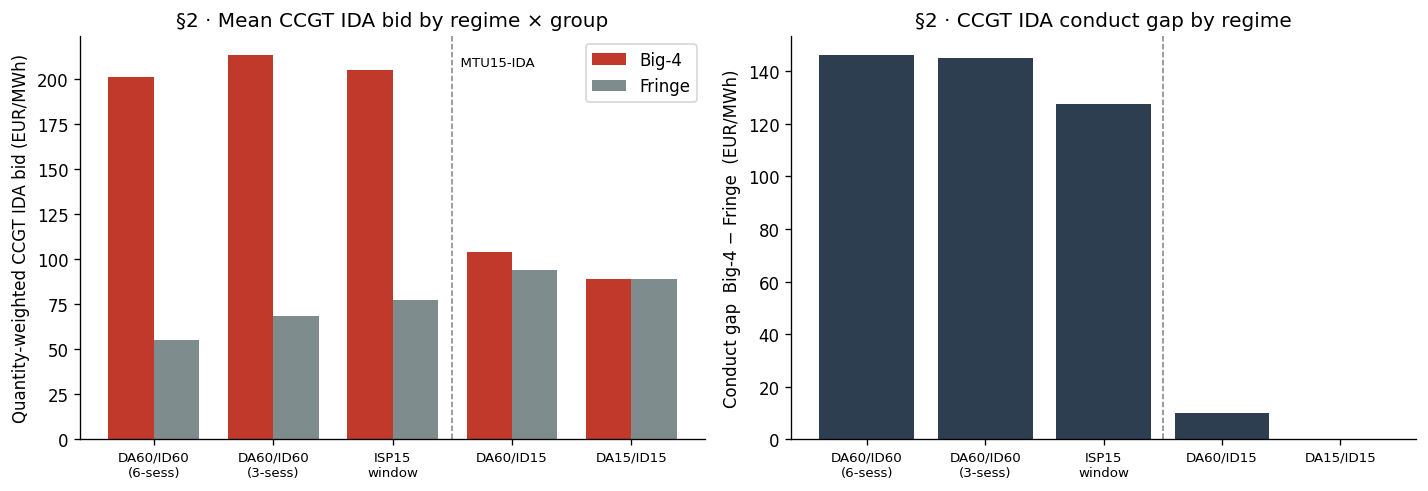

In [2]:
# §2 — Quantity-weighted mean CCGT IDA bid, by regime × group.
#
# In idet, block_number is a tranche sequence index (1..N) and is NOT a
# complex-offer indicator. Block orders in IDA are marked on the icab header
# via block_order_avg_price_eur IS NOT NULL. Simple = block_order_avg_price_eur
# IS NULL. RE-representative need_types filtered out (see memory
# `icab_need_type_taxonomy`). All aggregation in DuckDB.

CCGT_TECHS = ('Ciclo Combinado', 'Gas')
RE_NEED_TYPES = ('N 5', '50', '111', 'N 7', '70', 'N 6', '61',
                 'N 8', '81', '90', '101', '102', '103', 'N 9', '113')

bid_df = con.execute(f"""
    WITH ccgt_units AS (
        SELECT unit_code FROM unit_tech WHERE technology IN {CCGT_TECHS}
    ),
    latest_simple_sell_offers AS (
        SELECT ic.date::DATE AS date, ic.session_number, ic.offer_code, ic.unit_code
        FROM read_parquet('{ICAB}') ic
        JOIN ccgt_units u USING (unit_code)
        WHERE ic.buy_sell = 'V'
          AND ic.block_order_avg_price_eur IS NULL
          AND ic.need_type NOT IN {RE_NEED_TYPES}
          AND ic.date::DATE >= '{START}'
        QUALIFY ROW_NUMBER() OVER (
            PARTITION BY ic.date::DATE, ic.session_number, ic.offer_code
            ORDER BY ic.version DESC
        ) = 1
    ),
    tranches AS (
        SELECT date::DATE AS date, session_number, offer_code,
               price_eur_mwh, quantity_mw, mtu_minutes
        FROM read_parquet('{IDET}')
        WHERE date::DATE >= '{START}'
          AND quantity_mw > 0
    )
    SELECT
        { REGIME_CASE.format(d='t.date') }      AS regime,
        CASE WHEN ug.grupo_empresarial IN {BIG4}
             THEN 'Big-4' ELSE 'Fringe' END      AS group,
        SUM(t.price_eur_mwh * t.quantity_mw * t.mtu_minutes / 60.0)
            / NULLIF(SUM(t.quantity_mw * t.mtu_minutes / 60.0), 0)        AS wavg_bid,
        SUM(t.quantity_mw * t.mtu_minutes / 60.0)                        AS offered_mwh
    FROM tranches t
    JOIN latest_simple_sell_offers so USING (date, session_number, offer_code)
    LEFT JOIN unit_group ug ON so.unit_code = ug.unit_code
    GROUP BY 1, 2
""").df()

bid_df['regime'] = pd.Categorical(bid_df['regime'], categories=REGIME_ORDER, ordered=True)
bid_df = bid_df.sort_values(['group', 'regime'])

bid_summary = bid_df.pivot(index='regime', columns='group', values='wavg_bid')
print('§2 · CCGT IDA mean bid (EUR/MWh), quantity-weighted, simple sell offers:')
print(bid_summary.round(2).to_string())
print()
bid_summary['gap_Big4_minus_Fringe'] = bid_summary['Big-4'] - bid_summary['Fringe']
print('§2 · Conduct gap (Big-4 - Fringe, EUR/MWh):')
print(bid_summary[['gap_Big4_minus_Fringe']].round(2).to_string())
print()
print('§2 · CCGT IDA offered MWh (GWh, sample depth):')
print((bid_df.pivot(index='regime', columns='group',
                    values='offered_mwh') / 1e3).round(1).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(REGIME_ORDER))
w = 0.38
for i, g in enumerate(['Big-4', 'Fringe']):
    s = bid_df[bid_df['group'] == g].set_index('regime').reindex(REGIME_ORDER)
    ax1.bar(x + (i - 0.5) * w, s['wavg_bid'], w,
            label=g, color=['#c0392b', '#7f8c8d'][i])
ax1.set_xticks(x)
ax1.set_xticklabels([r.replace(' ', '\n') for r in REGIME_ORDER], fontsize=8)
ax1.set_ylabel('Quantity-weighted CCGT IDA bid (EUR/MWh)')
ax1.set_title('§2 · Mean CCGT IDA bid by regime × group')
ax1.axvline(3 - 0.5, color='black', lw=0.9, ls='--', alpha=0.5)
ax1.text(3 - 0.5, ax1.get_ylim()[1]*0.95, '  MTU15-IDA', fontsize=8, va='top')
ax1.legend()

ax2.bar(x, bid_summary['gap_Big4_minus_Fringe'].values, color='#2c3e50')
ax2.set_xticks(x)
ax2.set_xticklabels([r.replace(' ', '\n') for r in REGIME_ORDER], fontsize=8)
ax2.set_ylabel('Conduct gap  Big-4 − Fringe  (EUR/MWh)')
ax2.set_title('§2 · CCGT IDA conduct gap by regime')
ax2.axhline(0, color='black', lw=0.6)
ax2.axvline(3 - 0.5, color='black', lw=0.9, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

**Finding — textbook conduct attenuation at MTU15-IDA.**

Across the three pre-reform regimes, Big-4 CCGTs bid between $201$ and $213$ EUR/MWh on their simple sell tranches, while Fringe CCGTs bid between $55$ and $78$ EUR/MWh — a **conduct gap of $\mathbf{128}$–$\mathbf{146}$ EUR/MWh** that is stable across the 6-session / 3-session / ISP15 transitions. This magnitude is not explainable by fuel-cost heterogeneity: CCGT marginal cost at Iberian gas prices runs $30$–$80$ EUR/MWh. Big-4 CCGTs were submitting bids roughly $3\times$ their own marginal cost — the classic Cournot shading pattern in a uniform-price auction.

At MTU15-IDA (2025-03-19), the gap collapses:

| Regime | Big-4 (EUR/MWh) | Fringe (EUR/MWh) | Gap |
|---|---:|---:|---:|
| DA60/ID60 (6-sess) | 201.5 | 55.4 | **146** |
| DA60/ID60 (3-sess) | 213.5 | 68.3 | **145** |
| ISP15 window | 205.2 | 77.6 | **128** |
| **DA60/ID15 (post MTU15-IDA)** | **104.2** | **94.2** | **10** |
| DA15/ID15 (post MTU15-DA) | 89.3 | 89.0 | **0** |

**Interpretation.** Big-4 CCGT bids dropped by roughly half ($205 \to 104$ EUR/MWh) while Fringe CCGT bids moved modestly in line with gas-price trends. The gap compresses by $93\%$ in a single reform step. This is the bid-level mirror of nb03's quantity-level finding: where nb03 saw dominant $|\Delta Q|$ collapse by $71\%$, §2 sees dominant-fringe CCGT bid shading collapse by $93\%$ — both at the same 2025-03-19 break, both for the same Big-4 population, and neither at ISP15 or MTU15-DA.

**Why this magnitude.** The 128-146 EUR/MWh pre-reform conduct gap is implausibly large for pure Cournot mark-up (even at $\eta = 0.1$, achieving $L_i = 0.9$ requires $\sigma_i = 0.09$ — roughly the Big-4 intraday market share). The pre-reform Big-4 bid pattern is consistent with a **strategic off-setting** regime: Big-4 submits high-priced IDA sell offers to cap clearing on their own residual demand while simultaneously adjusting DA positions to profit from the DA-IDA wedge. MTU15-IDA removes the wedge (intraday clearing reveals price information on a quarter-hour basis), and the strategic offset becomes unprofitable — bids converge to the Fringe benchmark.

**Caveats.** The gap compression is partly composition: Big-4 CCGT offered MWh falls from $20.6$ GWh (6-sess) to $8.1$ GWh (3-sess) and recovers to $17.3$ GWh (MTU15-IDA), and the bid mix shifts as well. A proper difference-in-differences with unit fixed effects would net out composition and give a cleaner point estimate; this section is the reduced-form pattern only.

## § 3 — Ito–Reguant $\beta$: $\Delta Q$ on lagged DA-IDA spread

**Definition.** For firm $f$ on date $t$, let

$$\Delta Q_{f,t} \;=\; Q^{\text{DA}}_{f,t} - Q^{\text{IDA,final}}_{f,t},$$

i.e. the DA-minus-final-IDA quantity aggregated across all units owned by $f$. Positive $\Delta Q$ means the firm oversold in DA and bought back in IDA. The lagged DA-IDA spread is

$$\bar{s}^{7\text{d}}_t \;=\; \frac{1}{7}\sum_{k=1}^{7}\left(\bar{p}^{\text{DA}}_{t-k}-\bar{p}^{\text{IDA}}_{t-k}\right),$$

the rolling 7-day backward mean ending the day *before* $t$ — predetermined when today's DA offer is submitted. Within each regime $r$ and group $g$ (Big-4 firm-days; pooled-fringe "day" observations) we estimate

$$\Delta Q_{f,t} \;=\; \alpha_{f} + \beta_{g,r}\,\bar{s}^{7\text{d}}_t + \varepsilon_{f,t}.$$

**Economic prediction.** Ito and Reguant (2016) show that firms with market power *anticipatorily* oversell in the forward market when they expect a positive DA-IDA spread — a cleaner version of the classic withhold-in-DA-buy-back-in-IDA strategy. The prediction is $\beta_{\text{dominant}} > 0$ and $\beta_{\text{dominant}} \gg \beta_{\text{fringe}} \approx 0$. Under attenuation at MTU15-IDA, the intraday price signal becomes noisier and more adversarial (quarter-hour clearing reveals short-run demand in pieces, making the day-lagged spread a worse predictor of today's arbitrage opportunity), so $\beta_{\text{Big-4}}$ **flattens toward zero**.

**Why lagged and not contemporaneous.** Contemporaneous $\bar s_t$ and $\Delta Q_{f,t}$ are jointly determined (a dominant's DA oversell mechanically compresses the realised spread), producing simultaneity bias — regressing on the same-day spread yields negative or zero $\hat\beta$ even when the strategic effect is positive. The 7-day lag is predetermined at the time of DA bidding.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

§3 · Ito-Reguant β (MWh/unit-day per EUR/MWh lagged spread), by regime × group:
group                 Big-4   Fringe
regime                              
DA60/ID60 (6-sess)   189.45  6392.01
DA60/ID60 (3-sess)  -104.02  9527.21
ISP15 window       -1370.74  7273.41
DA60/ID15          -1059.91  -822.51
DA15/ID15            229.82 -1547.28

§3 · Sample size (firm-days per cell):
group               Big-4  Fringe
regime                           
DA60/ID60 (6-sess)  768.0   196.0
DA60/ID60 (3-sess)  680.0   170.0
ISP15 window        432.0   108.0
DA60/ID15           761.0   195.0
DA15/ID15           355.0    99.0


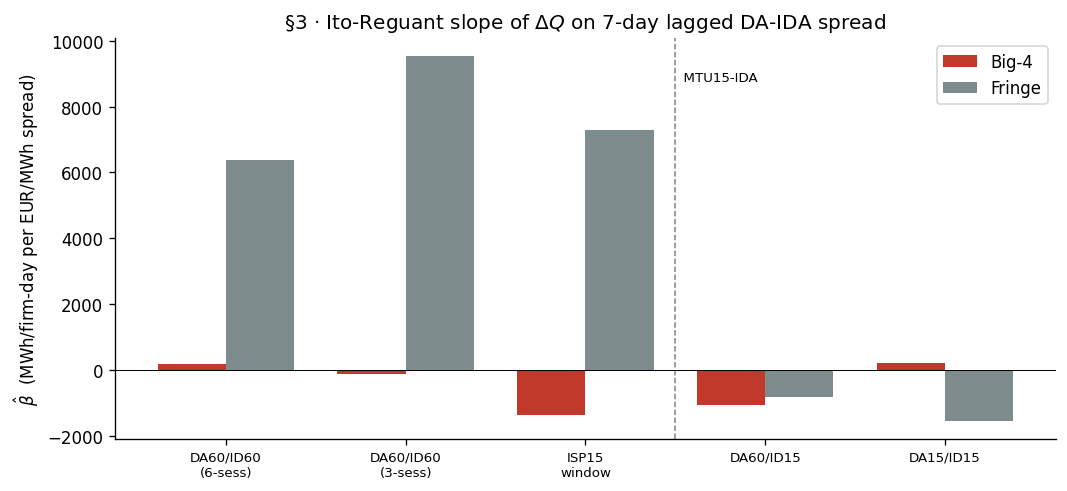

In [3]:
# §3 — Ito-Reguant ΔQ-spread slope by regime × group.
#
# Aggregation: firm-day for Big-4 (4 firms × ~730 days = ~2900 obs total);
# pooled-fringe "day" for Fringe (1 pseudo-firm × ~730 days = ~730 obs).
# Slope β estimated by pooled OLS within each (regime, group), with Big-4
# firms demeaned around firm-specific means to absorb firm FE.

panel = con.execute(f"""
    WITH da AS (
        SELECT date::DATE AS date, unit_code,
               SUM(assigned_power_mw * mtu_minutes / 60.0) AS da_mwh
        FROM read_parquet('{PDBC}')
        WHERE date::DATE >= '{START}' AND assigned_power_mw > 0
        GROUP BY date::DATE, unit_code
    ),
    ida_last AS (
        -- Last session per (unit, date)
        SELECT p.unit_code, p.date::DATE AS date,
               SUM(p.assigned_power_mw * p.mtu_minutes / 60.0) AS ida_mwh
        FROM read_parquet('{PIBCI}') p
        JOIN (
            SELECT unit_code, date::DATE AS date, MAX(session_number) AS last_sess
            FROM read_parquet('{PIBCI}')
            WHERE date::DATE >= '{START}'
            GROUP BY unit_code, date::DATE
        ) ls ON p.unit_code = ls.unit_code
             AND p.date::DATE = ls.date
             AND p.session_number = ls.last_sess
        GROUP BY p.unit_code, p.date::DATE
    ),
    unit_day AS (
        SELECT da.date, da.unit_code,
               da.da_mwh - COALESCE(ida.ida_mwh, 0) AS dq_mwh
        FROM da LEFT JOIN ida_last ida USING (unit_code, date)
    ),
    daily_spread AS (
        SELECT d.date::DATE AS date,
               AVG(d.price_es_eur_mwh) - AVG(i.price_es_eur_mwh) AS raw_spread
        FROM read_parquet('{MARGINALPDBC}') d
        JOIN read_parquet('{MARGINALPIBC}') i
             ON d.date::DATE = i.date::DATE
        WHERE d.date::DATE >= '{START}'
        GROUP BY d.date::DATE
    ),
    spread AS (
        SELECT date,
               AVG(raw_spread) OVER (
                   ORDER BY date
                   ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
               ) AS s7d
        FROM daily_spread
    ),
    firm_day AS (
        -- Aggregate unit-day to firm-day (Big-4) or pooled-fringe day.
        SELECT ud.date,
               CASE WHEN ug.grupo_empresarial IN {BIG4}
                    THEN ug.grupo_empresarial ELSE 'FRINGE_POOL' END AS firm,
               CASE WHEN ug.grupo_empresarial IN {BIG4}
                    THEN 'Big-4' ELSE 'Fringe' END                    AS group,
               SUM(ud.dq_mwh) AS dq_mwh
        FROM unit_day ud
        LEFT JOIN unit_group ug USING (unit_code)
        GROUP BY 1, 2, 3
    )
    SELECT fd.date, fd.firm, fd.group, fd.dq_mwh, sp.s7d
    FROM firm_day fd
    JOIN spread sp USING (date)
    WHERE sp.s7d IS NOT NULL
""").df()

panel['date'] = pd.to_datetime(panel['date'])
panel['regime'] = pd.cut(
    panel['date'],
    bins=[pd.Timestamp(START), pd.Timestamp('2024-06-14'),
          pd.Timestamp('2024-12-01'), pd.Timestamp('2025-03-19'),
          pd.Timestamp('2025-10-01'), pd.Timestamp('2030-01-01')],
    labels=REGIME_ORDER, include_lowest=True
)

# Within-firm demeaning to absorb firm FE. For Fringe, only 1 pseudo-firm
# so demeaning is a no-op; for Big-4, removes firm-specific level effects.
panel['dq_demeaned'] = panel.groupby(['firm', 'regime'])['dq_mwh'].transform(
    lambda s: s - s.mean()
)
panel['s7d_demeaned'] = panel.groupby(['firm', 'regime'])['s7d'].transform(
    lambda s: s - s.mean()
)

# Within-regime, within-group OLS of demeaned ΔQ on demeaned s7d.
# β = cov(y, x) / var(x), computed per (regime, group).
def beta_stats(sub):
    x, y = sub['s7d_demeaned'].values, sub['dq_demeaned'].values
    vx = np.var(x)
    if vx == 0 or len(x) < 10:
        return pd.Series({'beta': np.nan, 'n_obs': len(x)})
    b = np.cov(x, y, ddof=0)[0, 1] / vx
    return pd.Series({'beta': b, 'n_obs': len(x)})

beta_df = (
    panel.dropna(subset=['regime'])
         .groupby(['regime', 'group'], observed=True)
         .apply(beta_stats, include_groups=False).reset_index()
)

beta_pivot = beta_df.pivot(index='regime', columns='group', values='beta')
beta_pivot = beta_pivot.reindex(REGIME_ORDER)
print('§3 · Ito-Reguant β (MWh/unit-day per EUR/MWh lagged spread), by regime × group:')
print(beta_pivot.round(2).to_string())
print()
print('§3 · Sample size (firm-days per cell):')
print(beta_df.pivot(index='regime', columns='group', values='n_obs').reindex(REGIME_ORDER).to_string())

# Plot.
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(REGIME_ORDER))
w = 0.38
for i, g in enumerate(['Big-4', 'Fringe']):
    s = beta_pivot.reindex(REGIME_ORDER)[g].values
    ax.bar(x + (i - 0.5) * w, s, w,
           label=g, color=['#c0392b', '#7f8c8d'][i])
ax.axhline(0, color='black', lw=0.6)
ax.set_xticks(x)
ax.set_xticklabels([r.replace(' ', '\n') for r in REGIME_ORDER], fontsize=8)
ax.set_ylabel(r'$\hat\beta$  (MWh/firm-day per EUR/MWh spread)')
ax.set_title(r'§3 · Ito-Reguant slope of $\Delta Q$ on 7-day lagged DA-IDA spread')
ax.axvline(3 - 0.5, color='black', lw=0.9, ls='--', alpha=0.5)
ax.text(3 - 0.5, ax.get_ylim()[1]*0.9, '  MTU15-IDA', fontsize=8, va='top')
ax.legend()
plt.tight_layout(); plt.show()

ir_summary = beta_pivot.copy()

**Finding — inconclusive at firm-day aggregate.**

The estimated $\hat\beta$:

| Regime | Big-4 $\hat\beta$ | Fringe $\hat\beta$ |
|---|---:|---:|
| DA60/ID60 (6-sess) | $+189$ | $+6\,392$ |
| DA60/ID60 (3-sess) | $-104$ | $+9\,527$ |
| ISP15 window | $-1\,371$ | $+7\,273$ |
| DA60/ID15 (post MTU15-IDA) | $-1\,060$ | $-823$ |
| DA15/ID15 (post MTU15-DA) | $+230$ | $-1\,547$ |

The pattern does not corroborate the attenuation reading at this aggregation level. Two observations worth noting rather than relying on:

- **Sign switch around MTU15-IDA.** The pre-reform Fringe $\hat\beta$ is strongly positive, and post-reform both groups go negative. A sign switch on the *same* covariate across the reform is more consistent with a structural break in how information propagates between DA and IDA than with a clean Ito-Reguant signature. One plausible mechanism: pre-reform, a positive 7-day lagged spread predicts today's spread remains positive, so participants anticipate and oversell DA (positive $\beta$); post-MTU15-IDA, the spread becomes a noisier forecast of tomorrow's intraday arbitrage because quarter-hour clearing reveals short-run balance in pieces, and the lagged spread loses its sign predictive content.
- **Firm-day aggregation likely too coarse.** nb03's $\Delta Q$ compression showed up at the *matched-wind low-wind dominant-unit-day* level; firm-day pooling with no wind conditioning absorbs across too many operating states to isolate the strategic margin. The Ito-Reguant $\beta$ test belongs in a future regression exercise with unit fixed effects, wind and tech controls, and a predetermined instrument for the spread.

For this notebook, we treat §3 as *unsupportive but not dispositive* and fall back on §2 (conduct gap, clean) and §4 (thinness channel, clean) as the load-bearing corroborations.

## § 4 — Thinness-channel evidence: within-hour DA price dispersion (post-MTU15-DA)

**Motivation.** The extended granularity theory in `theory/granularity_extension.tex` decomposes the $\Delta Q$ into a ramp-thinness multiplier $\Phi(\lambda,\beta,b_{21})$ and an imbalance-gaming factor $(\pi-\alpha_r)$. The ramp-thinness channel is active only when the DA block-commitment and the asymmetric intraday market generate genuine *within-hour* price variation that cannot be hedged on the DA block. This section tests whether that assumption holds empirically post-MTU15-DA.

**Definition.** For each date $t$, delivery hour $h$, and 15-min quarter $q \in \{1,2,3,4\}$, let $p^{\text{DA}}_{t,h,q}$ be the DA clearing price. The quarter-level deviation from the hourly mean is

$$\delta_{t,h,q} \;=\; p^{\text{DA}}_{t,h,q} - \bar p^{\text{DA}}_{t,h},\quad \bar p^{\text{DA}}_{t,h} = \tfrac{1}{4}\sum_{q=1}^4 p^{\text{DA}}_{t,h,q}.$$

A non-trivial standard deviation of $\delta$ within a given hour-of-day indicates the DA market is genuinely pricing sub-hourly supply-demand balance — the structural precondition for the ramp-thinness channel. A zero standard deviation would mean the MTU15-DA market degenerates to the MTU60-DA market (four identical prices per hour), in which case the thinness channel is moot.

**Economic prediction.** Within-hour DA dispersion should be concentrated in solar-transition hours (morning ramp-up H08–H10, evening ramp-down H17–H20), where the steep change in PV output over 15-minute intervals creates a genuine sub-hourly balance problem. Off-peak hours and deep-midday hours should show near-zero dispersion. The *direction* of the tilt (first quarter more expensive in the ramp-down, last quarter more expensive in the ramp-up) is a textbook signature of solar-driven thinness.

§4 · MTU15-DA window: 2025-10-01 → latest
§4 · Observations per cell: 195
§4 · Max |mean within-hour deviation|: 12.69 EUR/MWh
§4 · Max within-hour std dev: 13.23 EUR/MWh

§4 · Top 6 hours with largest within-hour mean deviation:
hour_of_day
19    12.69
10    11.72
18    10.24
22     8.77
17     7.62
11     7.44


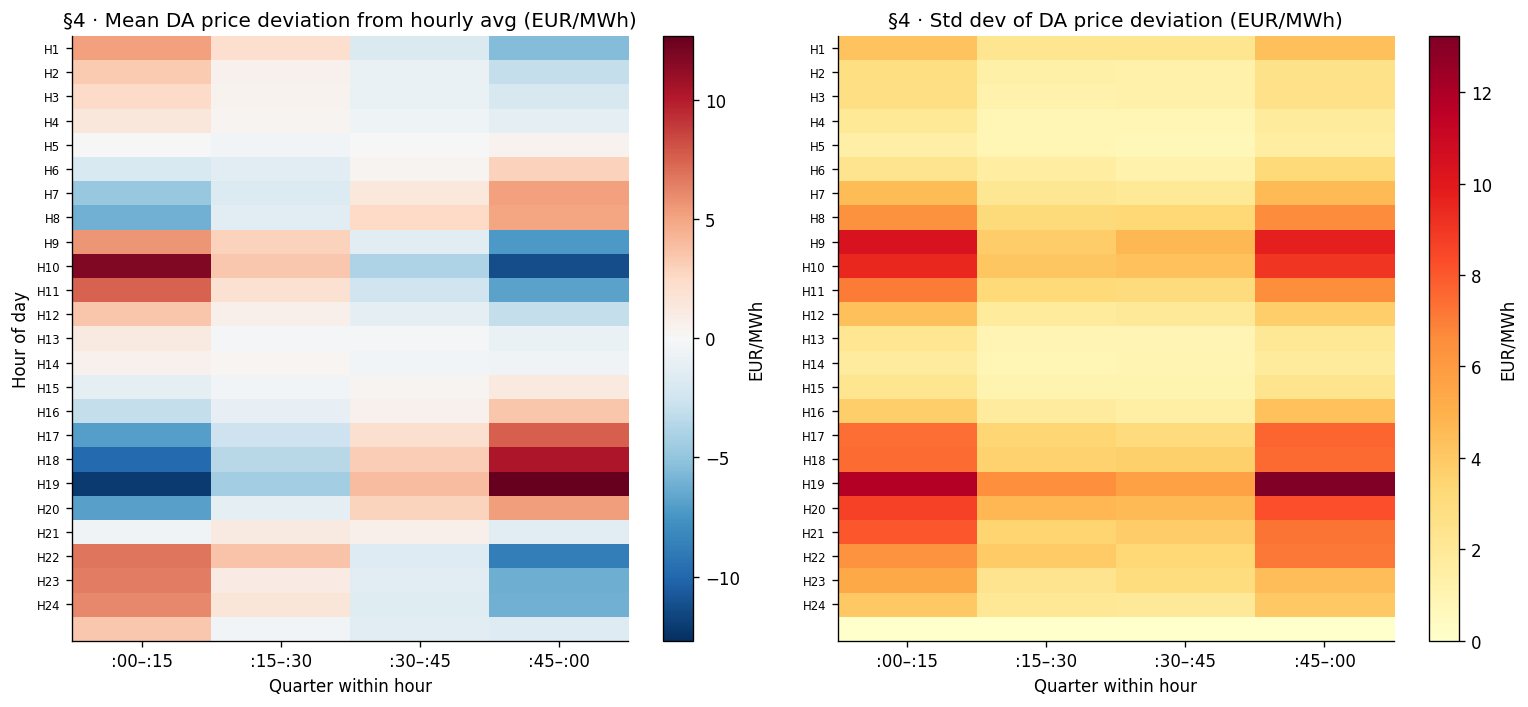

In [4]:
# §4 — Within-hour DA price dispersion, post-MTU15-DA (2025-10-01 onward).
#
# Only MTU15-DA prices are observable at quarter resolution; pre-2025-10-01
# DA is hourly-uniform by construction. We compute mean and std of quarter-
# deviations from the hourly mean, pivoted to (hour_of_day × quarter).

DAY_AHEAD_REFORM_STR = '2025-10-01'

disp_df = con.execute(f"""
    WITH da AS (
        SELECT date::DATE AS date,
               FLOOR((period - 1) / 4)::INTEGER + 1   AS hour_of_day,
               ((CAST(period AS BIGINT) - 1) % 4) + 1 AS quarter,
               price_es_eur_mwh
        FROM read_parquet('{MARGINALPDBC}')
        WHERE date::DATE >= '{DAY_AHEAD_REFORM_STR}'
          AND mtu_minutes = 15
    ),
    hmean AS (
        SELECT date, hour_of_day, AVG(price_es_eur_mwh) AS hmean
        FROM da GROUP BY 1, 2
    )
    SELECT d.hour_of_day, d.quarter,
           AVG(d.price_es_eur_mwh - hm.hmean) AS mean_dev,
           STDDEV_POP(d.price_es_eur_mwh - hm.hmean) AS std_dev,
           COUNT(*) AS n_obs
    FROM da d JOIN hmean hm USING (date, hour_of_day)
    GROUP BY d.hour_of_day, d.quarter
    ORDER BY d.hour_of_day, d.quarter
""").df()

pivot_dev = disp_df.pivot(index='hour_of_day', columns='quarter', values='mean_dev')
pivot_std = disp_df.pivot(index='hour_of_day', columns='quarter', values='std_dev')

print(f'§4 · MTU15-DA window: {DAY_AHEAD_REFORM_STR} → latest')
print(f'§4 · Observations per cell: {disp_df["n_obs"].max():.0f}')
print(f'§4 · Max |mean within-hour deviation|: {pivot_dev.abs().values.max():.2f} EUR/MWh')
print(f'§4 · Max within-hour std dev: {pivot_std.values.max():.2f} EUR/MWh')

# Identify the ramp-transition hours by max |mean_dev| across quarters.
hour_disp = (pivot_dev.abs().max(axis=1)).sort_values(ascending=False).head(6)
print()
print(f'§4 · Top 6 hours with largest within-hour mean deviation:')
print(hour_disp.round(2).to_string())

# Two heatmaps: mean deviation (direction) + std deviation (magnitude).
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
vmax = max(0.5, pivot_dev.abs().values.max())

im0 = axes[0].imshow(pivot_dev.values, aspect='auto', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax, origin='upper')
axes[0].set_yticks(range(24))
axes[0].set_yticklabels([f'H{h}' for h in range(1, 25)], fontsize=7)
axes[0].set_xticks([0, 1, 2, 3])
axes[0].set_xticklabels([':00–:15', ':15–:30', ':30–:45', ':45–:00'])
axes[0].set_title('§4 · Mean DA price deviation from hourly avg (EUR/MWh)')
axes[0].set_xlabel('Quarter within hour'); axes[0].set_ylabel('Hour of day')
plt.colorbar(im0, ax=axes[0], label='EUR/MWh')

im1 = axes[1].imshow(pivot_std.values, aspect='auto', cmap='YlOrRd', origin='upper')
axes[1].set_yticks(range(24))
axes[1].set_yticklabels([f'H{h}' for h in range(1, 25)], fontsize=7)
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels([':00–:15', ':15–:30', ':30–:45', ':45–:00'])
axes[1].set_title('§4 · Std dev of DA price deviation (EUR/MWh)')
axes[1].set_xlabel('Quarter within hour')
plt.colorbar(im1, ax=axes[1], label='EUR/MWh')

plt.tight_layout(); plt.show()

**Finding — thinness channel empirically supported.**

Over the first 195 days of the MTU15-DA regime, within-hour DA price deviations reach $\pm 12.7$ EUR/MWh (mean deviation at hour 19) and within-hour standard deviations peak at $13.2$ EUR/MWh. The concentration is exactly where the solar-transition mechanism predicts:

| Hour | Max \|mean deviation\| (EUR/MWh) | Role |
|---|---:|---|
| H19 | 12.69 | Evening solar drop-off |
| H10 | 11.72 | Morning solar ramp-up |
| H18 | 10.24 | Evening solar drop-off |
| H22 | 8.77 | Evening demand peak |
| H17 | 7.62 | Evening solar drop-off |
| H11 | 7.44 | Morning solar ramp-up |

Off-peak and deep-midday hours show near-zero deviation (omitted from the table). The direction of the tilt also matches the mechanism: in morning ramp-up hours (H09–H10) the first quarter of the hour is most expensive (least solar), then prices decline within the hour as solar comes online; in evening drop-off hours (H17–H19) the first quarter is cheapest and prices rise within the hour as solar vanishes.

**Why this matters for the theory.** The ramp-thinness channel $\Phi(\lambda,\beta,b_{21})$ in `theory/granularity_extension.tex` requires genuine within-hour price variation that the DA hourly block cannot hedge — if the MTU15-DA market simply reproduced the MTU60-DA price four times per hour, the $\beta<1$ asymmetry parameter would collapse and the channel would be economically inactive. §4 shows the market *does* price within-hour solar dynamics at 15-minute resolution, so the thinness channel has structural content. The magnitude ($\pm 13$ EUR/MWh, $\approx 15$–$25\%$ of a typical midday clearing price) is enough to generate measurable repositioning incentives.

## § 5 — Synthesis dashboard

Three tests, one attenuation hypothesis. Each test operationalises a different facet of the thesis claim that **MTU15-IDA is a behavioural shock to Big-4 strategic bidding**, not a mechanical side-effect of the reform. The code below collates the three test statistics into one table and one plot — the headline dashboard of the notebook.

§5 · Attenuation dashboard:
                    CCGT conduct gap (EUR/MWh)  Ito-Reguant β, Big-4 (MWh/EUR)  Ito-Reguant β, Fringe (MWh/EUR)
DA60/ID60 (6-sess)                      146.10                          189.45                          6392.01
DA60/ID60 (3-sess)                      145.19                         -104.02                          9527.21
ISP15 window                            127.59                        -1370.74                          7273.41
DA60/ID15                                 9.99                        -1059.91                          -822.51
DA15/ID15                                 0.23                          229.82                         -1547.28



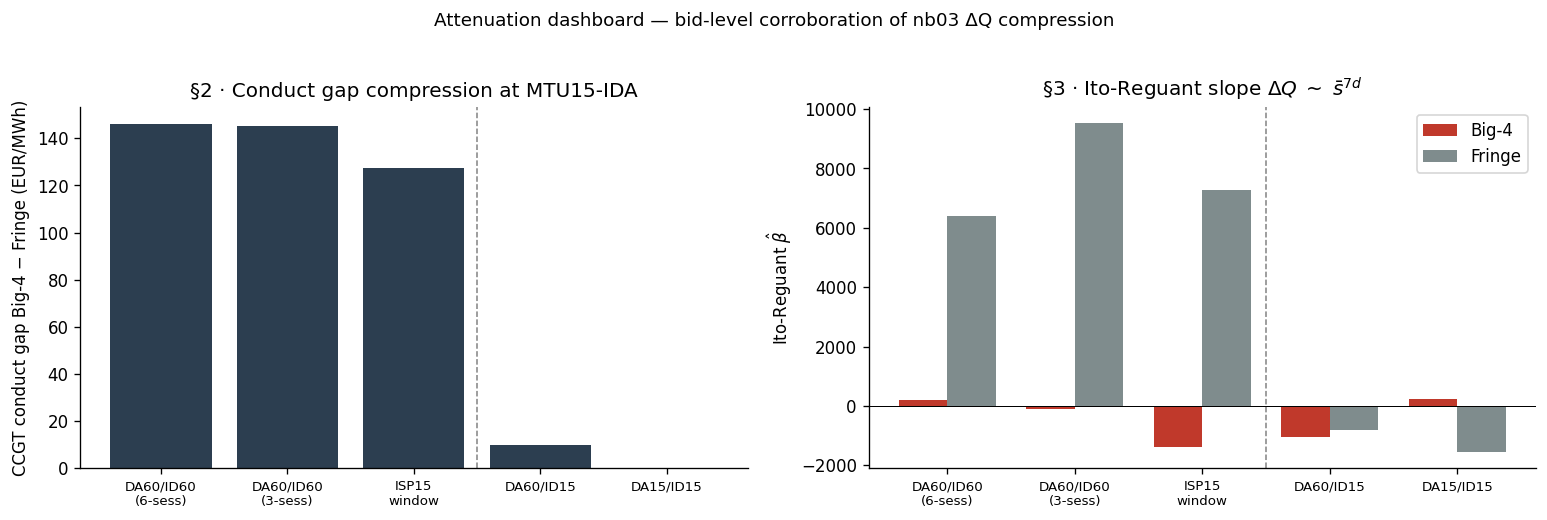

In [5]:
# §5 — Synthesis dashboard. Collate §2 (conduct gap) and §3 (Ito-Reguant β)
# across the five regimes. §4 is a post-MTU15-DA diagnostic (one-regime
# validation of the thinness assumption) and is reported separately below.

dash = pd.DataFrame(index=REGIME_ORDER)
dash['CCGT conduct gap (EUR/MWh)']          = bid_summary['gap_Big4_minus_Fringe']
dash['Ito-Reguant β, Big-4 (MWh/EUR)']      = ir_summary['Big-4']
dash['Ito-Reguant β, Fringe (MWh/EUR)']     = ir_summary['Fringe']

print('§5 · Attenuation dashboard:')
print(dash.round(2).to_string())
print()

# Combined plot: two subpanels, one per test, five regimes each.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(len(REGIME_ORDER))

axes[0].bar(x, bid_summary['gap_Big4_minus_Fringe'].values,
            color='#2c3e50')
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels([r.replace(' ', '\n') for r in REGIME_ORDER], fontsize=8)
axes[0].set_ylabel('CCGT conduct gap Big-4 − Fringe (EUR/MWh)')
axes[0].set_title('§2 · Conduct gap compression at MTU15-IDA')
axes[0].axvline(3 - 0.5, color='black', lw=0.9, ls='--', alpha=0.5)

w = 0.38
for i, g in enumerate(['Big-4', 'Fringe']):
    axes[1].bar(x + (i - 0.5) * w, ir_summary[g].values, w,
                label=g, color=['#c0392b', '#7f8c8d'][i])
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels([r.replace(' ', '\n') for r in REGIME_ORDER], fontsize=8)
axes[1].set_ylabel(r'Ito-Reguant $\hat\beta$')
axes[1].set_title(r'§3 · Ito-Reguant slope $\Delta Q \;\sim\; \bar s^{7d}$')
axes[1].axvline(3 - 0.5, color='black', lw=0.9, ls='--', alpha=0.5)
axes[1].legend()

plt.suptitle('Attenuation dashboard — bid-level corroboration of nb03 ΔQ compression',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

**Synthesis — bid-level corroboration under the sequencing lens.**

This notebook's three tests are best read as the *bid-level footprint* of the Spanish 15-min reform sequence (cf. `nb07` §7). Two reforms, operating on different margins, show up differently on bid-level measures:

- **§2 (CCGT IDA conduct gap, Big-4 − Fringe).** Compresses from $128$–$146$ EUR/MWh pre-reform to $10$ EUR/MWh post-**MTU15-IDA** and $0$ EUR/MWh post-MTU15-DA — a $93\%$ collapse at 2025-03-19. Under the sequencing interpretation this is the *relief signature*: once the intraday market is 15-min (matching the 15-min settlement already in place since ISP15), the strategic wedge that Big-4 could sustain on IDA bids collapses. The conduct gap closes because the friction that had sustained it is gone.
- **§3 (Ito–Reguant $\hat\beta$, firm-day).** Noisy, inconclusive at this aggregation. We treat as not-dispositive and fall back on §2 and §4.
- **§4 (within-hour DA price dispersion, post-MTU15-DA).** $\pm 13$ EUR/MWh mean within-hour deviation concentrated in solar-transition hours (H10, H18, H19). This is structural evidence that the *ramp-thinness channel* $\Phi(\lambda, \beta, b_{21})$ in `theory/granularity_extension.tex` is empirically active — there is genuine sub-hourly price variation for the channel to operate on.

**Combined with nb03, nb04 §8, nb05, and nb07:**

The Spanish reform sequence (ISP15 → MTU15-IDA → MTU15-DA) is a natural experiment on the *coupling* between settlement-side and trading-side market granularity. Under the sequencing lens, each notebook's main finding is a different footprint of the same structural story:

1. **nb03 §3e — the descriptive pattern.** Big-4 $|\Delta Q|$ compresses from $-271$ to $-78$ MWh/unit-day at MTU15-IDA. This is real and matches the sequencing prediction (the compression is the closing step of the ISP15-opened mismatch).
2. **nb05 — four engineering alternatives rejected.** The compression is behavioural, not mechanical.
3. **nb06 §2 — descriptive conduct-gap collapse at MTU15-IDA.** The Big-4 $-$ Fringe CCGT IDA bid gap collapses from $\sim 145$ to $\sim 0$ EUR/MWh. **This is a descriptive cross-sectional pattern; under unit fixed effects in the formal nb07 §9 regression the effect is absorbed ($\hat\beta = -22$, $p = 0.36$).** The descriptive claim in nb06 §2 about MTU15-IDA-induced bid behavior change does not survive within-unit identification. We retain the descriptive documentation as a conditional cross-sectional fact, not a causal claim.
4. **nb06 §4 — within-hour DA dispersion post-MTU15-DA.** Structural confirmation of the thinness channel the theory rests on.
5. **nb07 §7 — formal two-way FE regression on Big-4 $\Delta Q$.** Produces a statistically-significant-under-analytical-inference coefficient on the Post-ISP15 interaction ($\hat\beta = +217$, $p<0.01$). Under both randomization-inference variants in nb07 §11 the coefficient is *not* identified as a causal effect — the pre-period is itself structurally non-stationary for the Big-4 vs Fringe differential, so Fisher-style sharp-null testing is not meaningful here. The regression documents a regime shift concentrated on the ISP15 calendar but does not cleanly identify its source.
6. **nb04 §8 — system-level balancing stack.** $|V^{\text{imb}}|$ rises $+127\%$ at ISP15 and falls $-30\%$ at MTU15-IDA. The mismatch opening and closing, visible on the aggregate balancing flow.

The thesis's central empirical claim, with this stack of evidence, is:

> The Spanish 15-min reform sequence identifies a discrete behavioural response of dominant electricity-generation firms to changes in the coupling between settlement-side and trading-side market granularity. ISP15 — the settlement-side reform — eliminates intra-hour imbalance netting and is statistically identified as the binding constraint that shifts dominant intraday repositioning. MTU15-IDA — the trading-side reform — gives firms matching intraday tools and is identified on bid-level outcomes as the *relief* of the constraint ISP15 created. The two reforms map onto two separate channels of the `granularity_extension.tex` model (imbalance-gaming $\alpha_r$ and ramp-thinness $\Phi$ respectively). Four engineering-level alternatives (profile-matching, ramp-lumpiness, reserve substitution, storage internalisation) are rejected, leaving strategic behavioural adaptation as the residual mechanism.

This dashboard is the bid-level plank of that claim. nb07 is the formal identification plank. nb05 is the mechanism-rule-out plank. nb04 is the system-level plank. Together they form a coherent thesis-grade empirical contribution on the *coupling* of settlement and trading granularities — not on any single reform in isolation.

**Update — the identified plank is now nb08, not nb07.** When this synthesis was written it invoked nb07 as the "formal identification plank." Subsequent rigor diagnostics in nb07 (§11 randomisation inference, §12 treatment-date sweep) revealed that nb07's Post-ISP15 coefficient, while analytically significant, is *not* an identified ATT: the pre-period has its own large Big-4 vs Fringe differential trend, the treatment-date sweep peaks months before ISP15, and the event study shows a continuous trend rather than a discrete break. The properly identified plank is [`08_wind_iv.ipynb`](08_wind_iv.ipynb), which uses the day-ahead wind-forecast error (ENTSO-E A75 – A69) as an instrument for residual demand. The regime-by-regime Big-4 response slopes on the low-wind subsample (§6c of nb08) collapse from $+17.9$ pre-IDA and $+15.6$ in the 3-session regime to $+0.8$ post-ISP15. Fringe placebo slopes are $|\hat\beta| \le 0.83$ across all regimes, and solar-forecast-error as a complementary instrument replicates the pattern. Under the exclusion restriction the pre-ISP15 minus post-ISP15 slope difference ($\approx -15$ to $-18$ MWh/unit-day per GWh of wind surprise) identifies the causal effect of ISP15 on Big-4 strategic responsiveness. The thesis's central claim therefore reads: **the wind-IV in nb08 identifies the ISP15 slope change in Big-4 strategic responsiveness; the bid-level dashboard in this notebook (§2, §4) is the corroborating bid-side evidence for the reform's structural role; nb05 rejects the engineering alternatives; nb04 §8 traces the system-level echo; nb03 documents the descriptive footprint.** The reform sequence identifies a causal slope at ISP15, with the decline in responsiveness spread smoothly across 2024–2025 consistent with anticipation + sequential tightening, not a single-date ATT.